# Convolutional Neural Network's:
* torchvision : library for CV(computer vision)


In [5]:
import torch
from torch import nn
import torchvision
from torchvision import models
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchvision import datasets

import matplotlib.pyplot as plt
import numpy as np

ModuleNotFoundError: No module named 'torch'

In [6]:
# Normalize
Transform = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                                                    std=(0.2023, 0.1994, 0.2010))
                               ])

trainset = torchvision.datasets.CIFAR10(
    root = "./data",
    train= True,
    transform = Transform,
    download=True,
    target_transform=None
)

testset = torchvision.datasets.CIFAR10(
    root = "./data",
    train = False,
    transform = Transform,
    download = True)



NameError: name 'transforms' is not defined

In [7]:
print(testset[0])

NameError: name 'testset' is not defined

In [8]:
image, label = trainset[0]
print(image.max(), image.min())

NameError: name 'trainset' is not defined

In [5]:
image.shape

torch.Size([3, 32, 32])

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

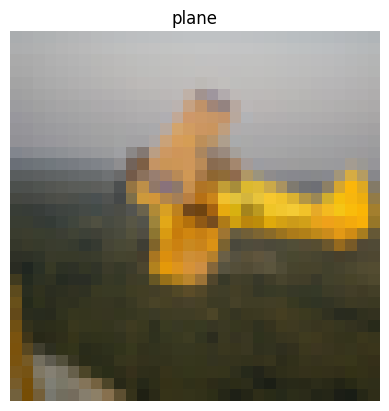

In [6]:
def denormalize(img_tensor, mean, std):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    return img_tensor * std + mean

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

image, label = trainset[1234]

# Undo normalization
#[ x = (x * stdandard deviation) + mean ]
image = denormalize(image, (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))


# Convert to numpy from [clr, height, width] -> [height, width, colr]
image = image.numpy().transpose((1, 2, 0))

#plot
plt.imshow(image)
plt.title(f"{classes[label]}")
plt.axis("off")

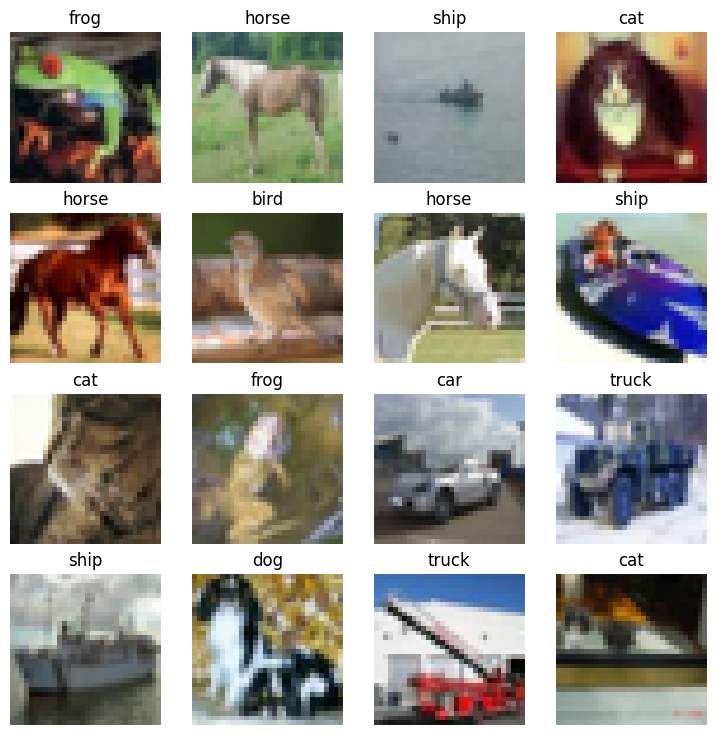

In [7]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows*cols + 1):
  random_idx = torch.randint(len(trainset), size=[1]).item()
  img, label = trainset[random_idx]
  fig.add_subplot(rows, cols, i)
  image = denormalize(img, mean=(0.4914, 0.4822, 0.4465),
                                                    std=(0.2023, 0.1994, 0.2010) )
  image = image.numpy().transpose((1, 2, 0))
  # Plot
  plt.imshow(image)
  plt.title(classes[label])
  plt.axis(False)

plt.show()

In [8]:
# Prepare data loader
import torch
train_data_loader = torch.utils.data.DataLoader(trainset, batch_size = 35, shuffle=True)
test_data_loader = torch.utils.data.DataLoader(testset, batch_size = 35, shuffle=True)

print(f"Trainset_dataloader : {train_data_loader} | Testset_dataloader : {test_data_loader}")
print(f"Trainset  : {len(train_data_loader)} | Testset  : {len(test_data_loader)}")


Trainset_dataloader : <torch.utils.data.dataloader.DataLoader object at 0x7918d0c7abd0> | Testset_dataloader : <torch.utils.data.dataloader.DataLoader object at 0x7918e4b5bfd0>
Trainset  : 1429 | Testset  : 286


In [9]:
# Device Agnostic Code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [10]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):
  """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
  loss = 0
  acc = 0
  model.eval()
  with torch.inference_mode():
    for image, label in data_loader:
      # Make predictions with the torch model
      image = image.to(device) # Move image to the same device as the model
      y_pred = model(image)

      # Accumulate the loss and accuracy values per batch
      loss += loss_fn(y_pred, label.to(device)) # Also move labels to the device
      acc += accuracy_fn(y_true=label.to(device), # Move labels to the device
                          y_pred=y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

In [11]:
# Creating a functions to time our experiments,
from timeit import default_timer as Timer

def print_train_time(start:float, end:float, device : torch.device = None):
  """Prints difference between start and end time.

  Args:
    start (float): Start time of computation (preferred in timeit format).
    end (float): End time of computation,
    device ([type], optional): Device that compute is running on. Defaults to None.

  Returns:
    float: time between start and end in seconds (higher is longer).
  """
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [12]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [13]:
# Building a baseline model

class CifarModelV0(nn.Module):
  def __init__(self, input_classes: int, hidden_units: int, output_classes: int):
    super().__init__()
    self.Layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_classes, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_classes)
    )
  def forward(self, c):
    return self.Layers(c)

model_0 = CifarModelV0(3072, 256, 10)
model_0.to(device)



CifarModelV0(
  (Layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [14]:
# Functioniize train and test loops

def training(model : torch.nn.Module,
             data_loader : torch.utils.data.DataLoader,
             loss_fn : torch.nn.Module,
             optimizer : torch.optim.Optimizer,
             accuracy_fn,
             device : torch.device = device
             ):
  train_loss = 0
  train_acc = 0
  model.train()
  for (image, label) in data_loader:

    image, label = image.to(device), label.to(device)
    y_pred = model(image)
    loss = loss_fn(y_pred, label)
    train_loss += loss
    train_acc += accuracy_fn(label, (y_pred).argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train Loss : {train_loss:.5f} | Train Accuracy : {train_acc:.2f}%")

def testing(model : torch.nn.Module,
            data_loader : torch.utils.data.DataLoader,
            loss_fn : torch.nn.Module,
            accuracy_fn,
            device : torch.device=device):

  test_loss = 0
  test_acc = 0
  model.eval()
  with torch.inference_mode():
    for image, label in data_loader:
      image, label = image.to(device), label.to(device)
      y_preds = model(image)
      loss = loss_fn(y_preds, label)
      test_loss += loss
      test_acc += accuracy_fn(label, (y_preds).argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
  print(f"Test Loss : {test_loss:.5f} | Test Accuracy : {test_acc:.2f}%")


In [15]:
# loss funtion and the optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),lr=0.1)

In [ ]:
# Traing and testing he model
from helper_functions import accuracy_fn
from tqdm import tqdm
train_time_start_on_gpu = Timer()

from timeit import default_timer as Timer
train_time_start_on_gpu = Timer()

epochs = 5
for epoch in tqdm(range(epochs)):
  training(model_0, train_data_loader, loss_fn, optimizer, accuracy_fn)
  testing(model_0, test_data_loader, loss_fn, accuracy_fn)

train_time_end_on_gpu = Timer()
total_train_time_model_0 = print_train_time(
  start=train_time_start_on_gpu,
  end=train_time_end_on_gpu,
  device=device)





  0%|          | 0/5 [00:00<?, ?it/s]

Train Loss : 1.92015 | Train Accuracy : 32.05%


 20%|██        | 1/5 [00:15<01:01, 15.39s/it]

Test Loss : 1.93365 | Test Accuracy : 31.51%


In [ ]:
model_0_results= eval_model(model_0,
           test_data_loader,
           loss_fn,
           accuracy_fn,
           device=device
           )
model_0_results

In [ ]:
# Convolutional Model
class CifarModelV1(nn.Module):
  def __init__(self, input_shape : int, hidden_units : int, output_shape : int):
    super().__init__()
    self.Layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features = output_shape)
    )
  def forward(self, x):
    return self.Layers(x)


In [ ]:
model_1 = CifarModelV1(input_shape=3072, hidden_units=100, output_shape=10)
model_1.to(device)
model_1

In [ ]:
#Loss Function and Optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [ ]:
# Training and Testing the model_1

epochs = 20

for epoch in tqdm(range(epochs)):
  print(f"\nEpoch [{epoch+1}/{epochs}]")
  print("--------------------------------------------------")
  training(
      model_1,
      train_data_loader,
      loss_fn,
      optimizer,
      accuracy_fn,
      device
  )

  testing(
      model_1,
      test_data_loader,
      loss_fn,
      accuracy_fn,
      device
  )

train_time_end_on_gpu = Timer()
total_train_time_model_1 = print_train_time(
  start=train_time_start_on_gpu,
  end=train_time_end_on_gpu,
  device=device)


In [ ]:
model_1_results = eval_model(model_1,
                             test_data_loader,
                             loss_fn,
                             accuracy_fn,
                             device=device
                             )
model_1_results

# Building a Convolutional Model
* nn.Conv2d : feature extraction
* nn.MaxPool2d : downsampling
* nn.Linear : classification

In [ ]:
image.shape

In [ ]:
# Convolutional Model:

class CifarModelV2(nn.Module):
  def __init__(self, input_shape : int, hidden_units : int, output_shape : int):
    super().__init__()
    # 32 x 32
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2
                     )
    )
    # reduced to 16 x 16
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2
                     )
    )
    # reduced to 8 x 8
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(p=0.5),
        nn.Linear(in_features=hidden_units*8*8, # 32 x 32 (reduced to) -> 16 x 16 -> 8 x 8 because of the previos 2 blocks
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

In [ ]:
model_2 = CifarModelV2(input_shape=3, hidden_units=256, output_shape=len(classes))
model_2.to(device)
model_2

In [ ]:
# optimizer
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
# Training an testing

epochs= 10
for epoch in range(epochs):
  print(f"Epoch : {epoch+1} / {epochs}")
  print("--------------------------------------------------")
  training(
      model_2,
      train_data_loader,
      loss_fn,
      optimizer,
      accuracy_fn,
      device=device
  )

  testing(
      model_2,
      test_data_loader,
      loss_fn,
      accuracy_fn,
      device=device
  )
  print("\n")

train_time_end_on_gpu = Timer()
total_train_time_model_2 = print_train_time(
  start=train_time_start_on_gpu,
  end=train_time_end_on_gpu,
  device=device)

In [ ]:
model_2_results = eval_model(model_2,
                             test_data_loader,
                             loss_fn,
                             accuracy_fn,
                             device=device
                             )
model_2_results

In [ ]:
# Combining the results of the models:
import pandas as pd
compare_results = pd.DataFrame((model_0_results, model_1_results, model_2_results))
compare_results

In [ ]:
compare_results["training_time"] = [
    total_train_time_model_0,
    total_train_time_model_1,
    total_train_time_model_2
    ]

compare_results

# Performance-speed tradeoff


In [ ]:
# Visualizing our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accurace (%)")
plt.ylabel("model");

# Ways to Improve Model Performance
* Add more Layers → deeper feature learning  
* Increase Hidden Units → capture complex patterns  
* Train Longer (More Epochs) → better convergence  
* Try Different Activations → ReLU, LeakyReLU, GELU  
* Change Loss Function → better suited for task  
* Tune Learning Rate → too high = unstable, too low = slow  
* Use Transfer Learning → reuse pre-trained knowledge  


In [ ]:
# Make an evaluate andom predictions with best model
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
  pred_probs_list = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare sample
      sample = torch.unsqueeze(sample, dim=0).to(device) # add extra dimentsion

      # Forward Pass (model outputs raw logits)
      pred_logits = model(sample)

      # Get preddiction probabilit (logit -> prediction probabiltiy)
      pred_probs = torch.softmax(pred_logits.squeeze(), dim=0)

      # Get pred_prob off GPU for further calculations
      pred_probs_list.append(pred_probs.cpu())

  # Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs_list)

In [ ]:
import random
test_samples = []
test_labels =[]
for sample, label in random.sample(list(testset), k=9):
  test_samples.append(sample)
  test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label : {test_labels[0]} ({classes[test_labels[0]]})")


In [ ]:
# Make predictions on test samples with model 2
pred_probs = make_predictions(model=model_2,
                              data=test_samples)
pred_probs[:2]

In [ ]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

In [ ]:
test_labels, pred_classes


In [ ]:
for i in range(len(test_labels)):
  print(f"{classes[test_labels[i]]} | {classes[pred_classes[i]]}")

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Denormalize and transpose the image
  image = denormalize(sample, mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010))
  image = image.numpy().transpose((1, 2, 0))

  # Plot the target image
  plt.imshow(image)

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = classes[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = classes[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

# Making a confusion matrix for further prediction evaluation
1. Make predictions with our trained model, `model_2` (a confusion matrix compares predictions to true labels).
2. Make a confusion matrix using torchmetrics.ConfusionMatrix
3. Plot the confusion using mlxtend.plotting.plot_confusion_matrix().


In [ ]:
from tqdm.auto import tqdm

# make predictions witht trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for image, label in tqdm(test_data_loader, desc="Making predictions"):
    # Send data and targets to target device
    image, label = image.to(device), label.to(device)
    # Do the forward pass
    y_logits = model_2(image)

    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    # put predictions on cpu for evalution
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

* Make a confusion matrix using `torchmetrics.ConfusionMatrix`.
* Plot the confusion matrix using `lxtend.plotting.plot_confusion_matrix()`.

In [ ]:
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 or higher"
except:
  !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

In [ ]:
# Import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import torch

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(classes), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=torch.tensor(testset.targets))

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy
    class_names=classes, # turn the row and column labels into class names
    figsize=(10, 7)
);